## Bank Marketing Campaign Prediction 
The project name is "Bank Marketing Campaign Prediction Machine Learning Project" which primarily deals with the data analysis of the customers obtained from the Portugal Banking company, in order to complement through the study of the data the variables which contribute in making the customer to further subscribe for the term deposit of the bank.

This notebook will touch upon the overall machine learning procedure from beginning to end. The project will be started off with collecting the data and learning it, using exploratory data analysis (EDA), going through the data cleaning, preprocessing, and feature engineering stages. Then, various classification methods will be applied to find out which method is useful for determining customer subscriptions. The hyperparameter tuning will also be performed to boost the quality of the model.Subsequently, the analysis of results will be done along with the identification of pros and cons of the models used during the project and possible recommendations for the bank in order to improve any marketing campaigns in the future.

Git Hub Repository:https://github.com/waleedkhanak19-cloud/intro--to--AI-and-ML

**Problem Statement**
Marketing campaigns are significant for the advertising of the banking products, but it may be expensive and ineffective to reach out the whole customer base. Only a small group of customers will tend to become the client of a term deposit. The goal of this project is to create a classification model of machine learning to predict the customers who are willing to be the subscribers.


*Why it is important?*

Customer subscription predictions are necessary since traditional marketing approaches frequently entail reaching out to many customers, even when the marketers have no way of knowing if the customers would be interested in the product. As a result, marketers spend a lot of money and effort with no guarantee that their messages would lead to real sales.

Machine learning would come in handy in this case, as it can study the customer's past behavior and determine which characteristics showed that a given customer is likely to subscribe. The predictive model allows the bank to improve the efficiency of its marketing by enabling it to target the customers who are more likely to subscribe.

*How Solving This Problem Will Benefit the Company?*

Improved Marketing Efficiency: Marketing campaigns can be directed to customers who are thought to be more likely to subscribe.
Cost-Friendly Operations: There would not be any unnecessary calls to customers who would not respond positively.
Increased Rate of Conversions: Successful subscriptions for term deposits can be made more likely.
Support of Data-Driven Decisions: Decisions made by marketing teams can be taken based on predictive analysis and data analysis based on the history of the customers.
Improved Customer Targeting: More personalized policies can be made.
Efficient Utilization of Resources: Employees can focus on customers with high chances of subscribing.

*How Would You Collect Relavent Data?*

source: https://archive.ics.uci.edu/dataset/222/bank+marketing

## Data loading and Overview

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report,ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier


In [5]:
df= pd.read_csv(r"C:\Users\dell\Desktop\ML_Project\bank-full.csv", sep=';')

In [6]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Exploratory Data Analysis

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [8]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


Observation: it calculates the statistical mesures for each feature

In [9]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


observation: the Data set does not contain any missing vaules 



In [10]:

df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
41183    False
41184    False
41185    False
41186    False
41187    False
Length: 41188, dtype: bool

## Target Value

In [11]:
df["y"].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

observation: it shows the total numbers of customers applied or not to a deposit

## Converted to Binary

In [12]:
df['y'] =df['y'].map({
    "no":0,
    "yes":1
})
print("\nBinary Target Distribution:")
print(df["y"].value_counts())


Binary Target Distribution:
y
0    36548
1     4640
Name: count, dtype: int64


observation: it converts the string into 0 and 1s

In [13]:
# Target percentage
df['y'].value_counts(normalize=True)*100

y
0    88.734583
1    11.265417
Name: proportion, dtype: float64

observation: it shows the percentage of the customers applied to the deposit

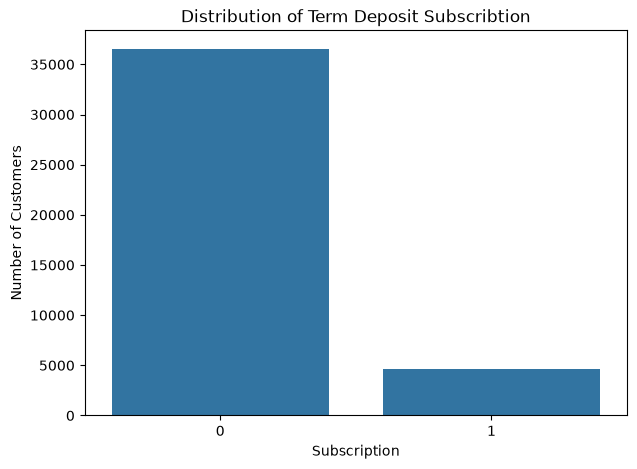

In [14]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="y")
plt.title("Distribution of Term Deposit Subscribtion")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")
plt.show()

Observation: the Bar chart shows the distribution  of customers for a deposit subscription.

## Data Preprocessing

In [15]:
numeric_cols= df.select_dtypes(include=np.number).columns.to_list()
categorical_cols= df.select_dtypes(include=["object","str"]).columns.to_list()
if 'y' in numeric_cols:
    numeric_cols.remove('y')
print("Numerical Columns:", numeric_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical Columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


observation: it separate the features into categorical and numerical columns

## Distribution of Categorical Features 

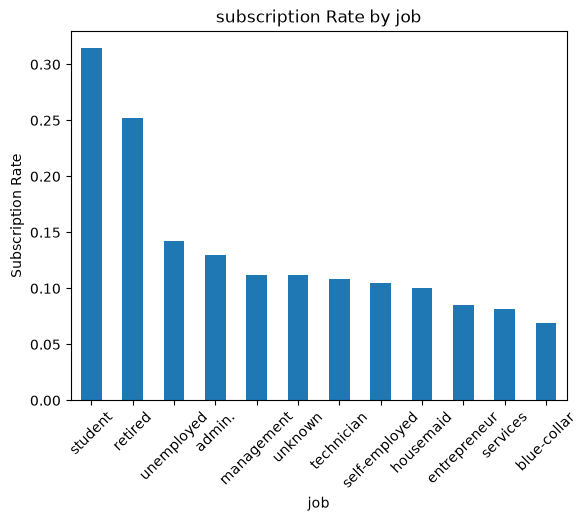

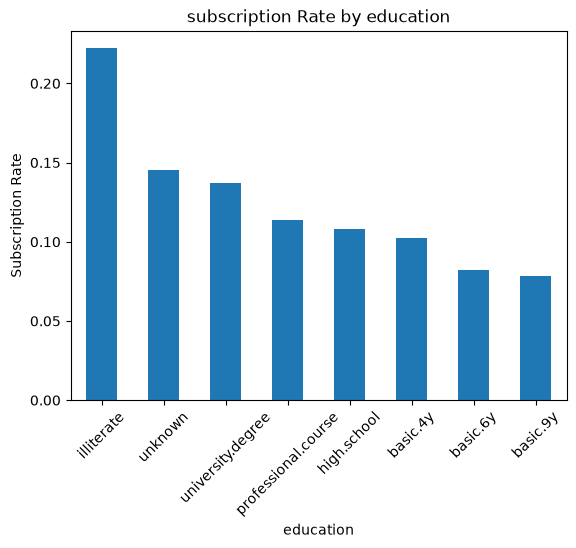

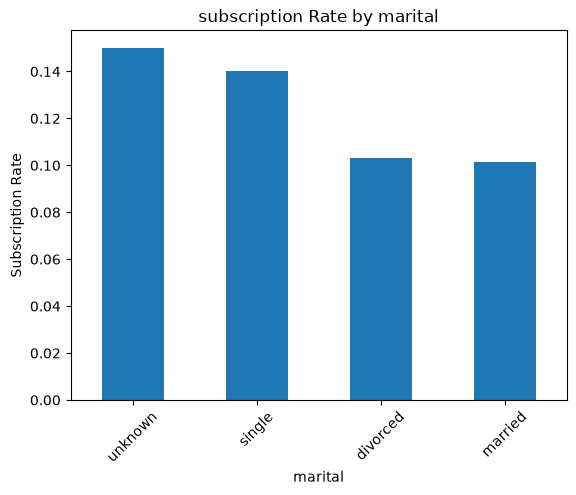

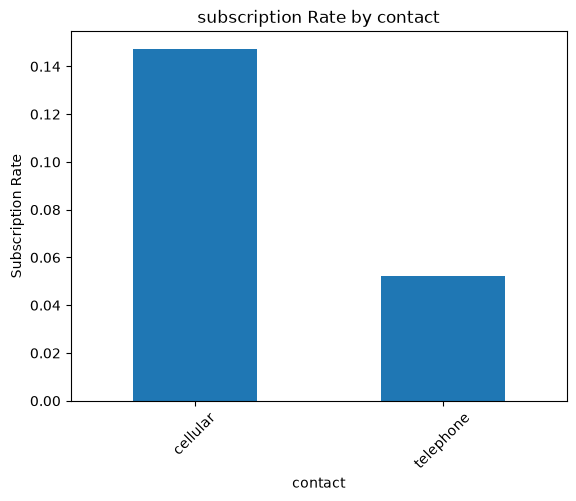

In [16]:
categorical_features = ["job","education","marital","contact"]
for feature in categorical_features:
    plt.Figure(figsize=(8,4))
    df.groupby(feature)["y"].mean().sort_values(
        ascending=False
    ).plot(kind="bar")
    plt.title(f"subscription Rate by {feature}")
    plt.ylabel("Subscription Rate")
    plt.xlabel(feature)
    plt.xticks(rotation=45)
    plt.show()

Oberseravtions: these graphs shows distribution  of subscriptions by categorical features. 

## Distribution of Numerical Features

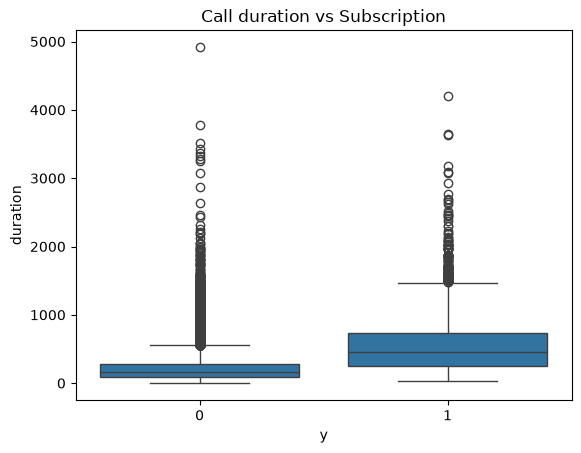

In [17]:
plt.Figure(figsize=(9,6))
sns.boxplot(
    data=df,
    x="y",
    y="duration"
)
plt.title("Call duration vs Subscription")
plt.show()

Observation: this boxplot graph shows the comparision between a customer call duration along with possiblility of subscription 

<function matplotlib.pyplot.show(close=None, block=None)>

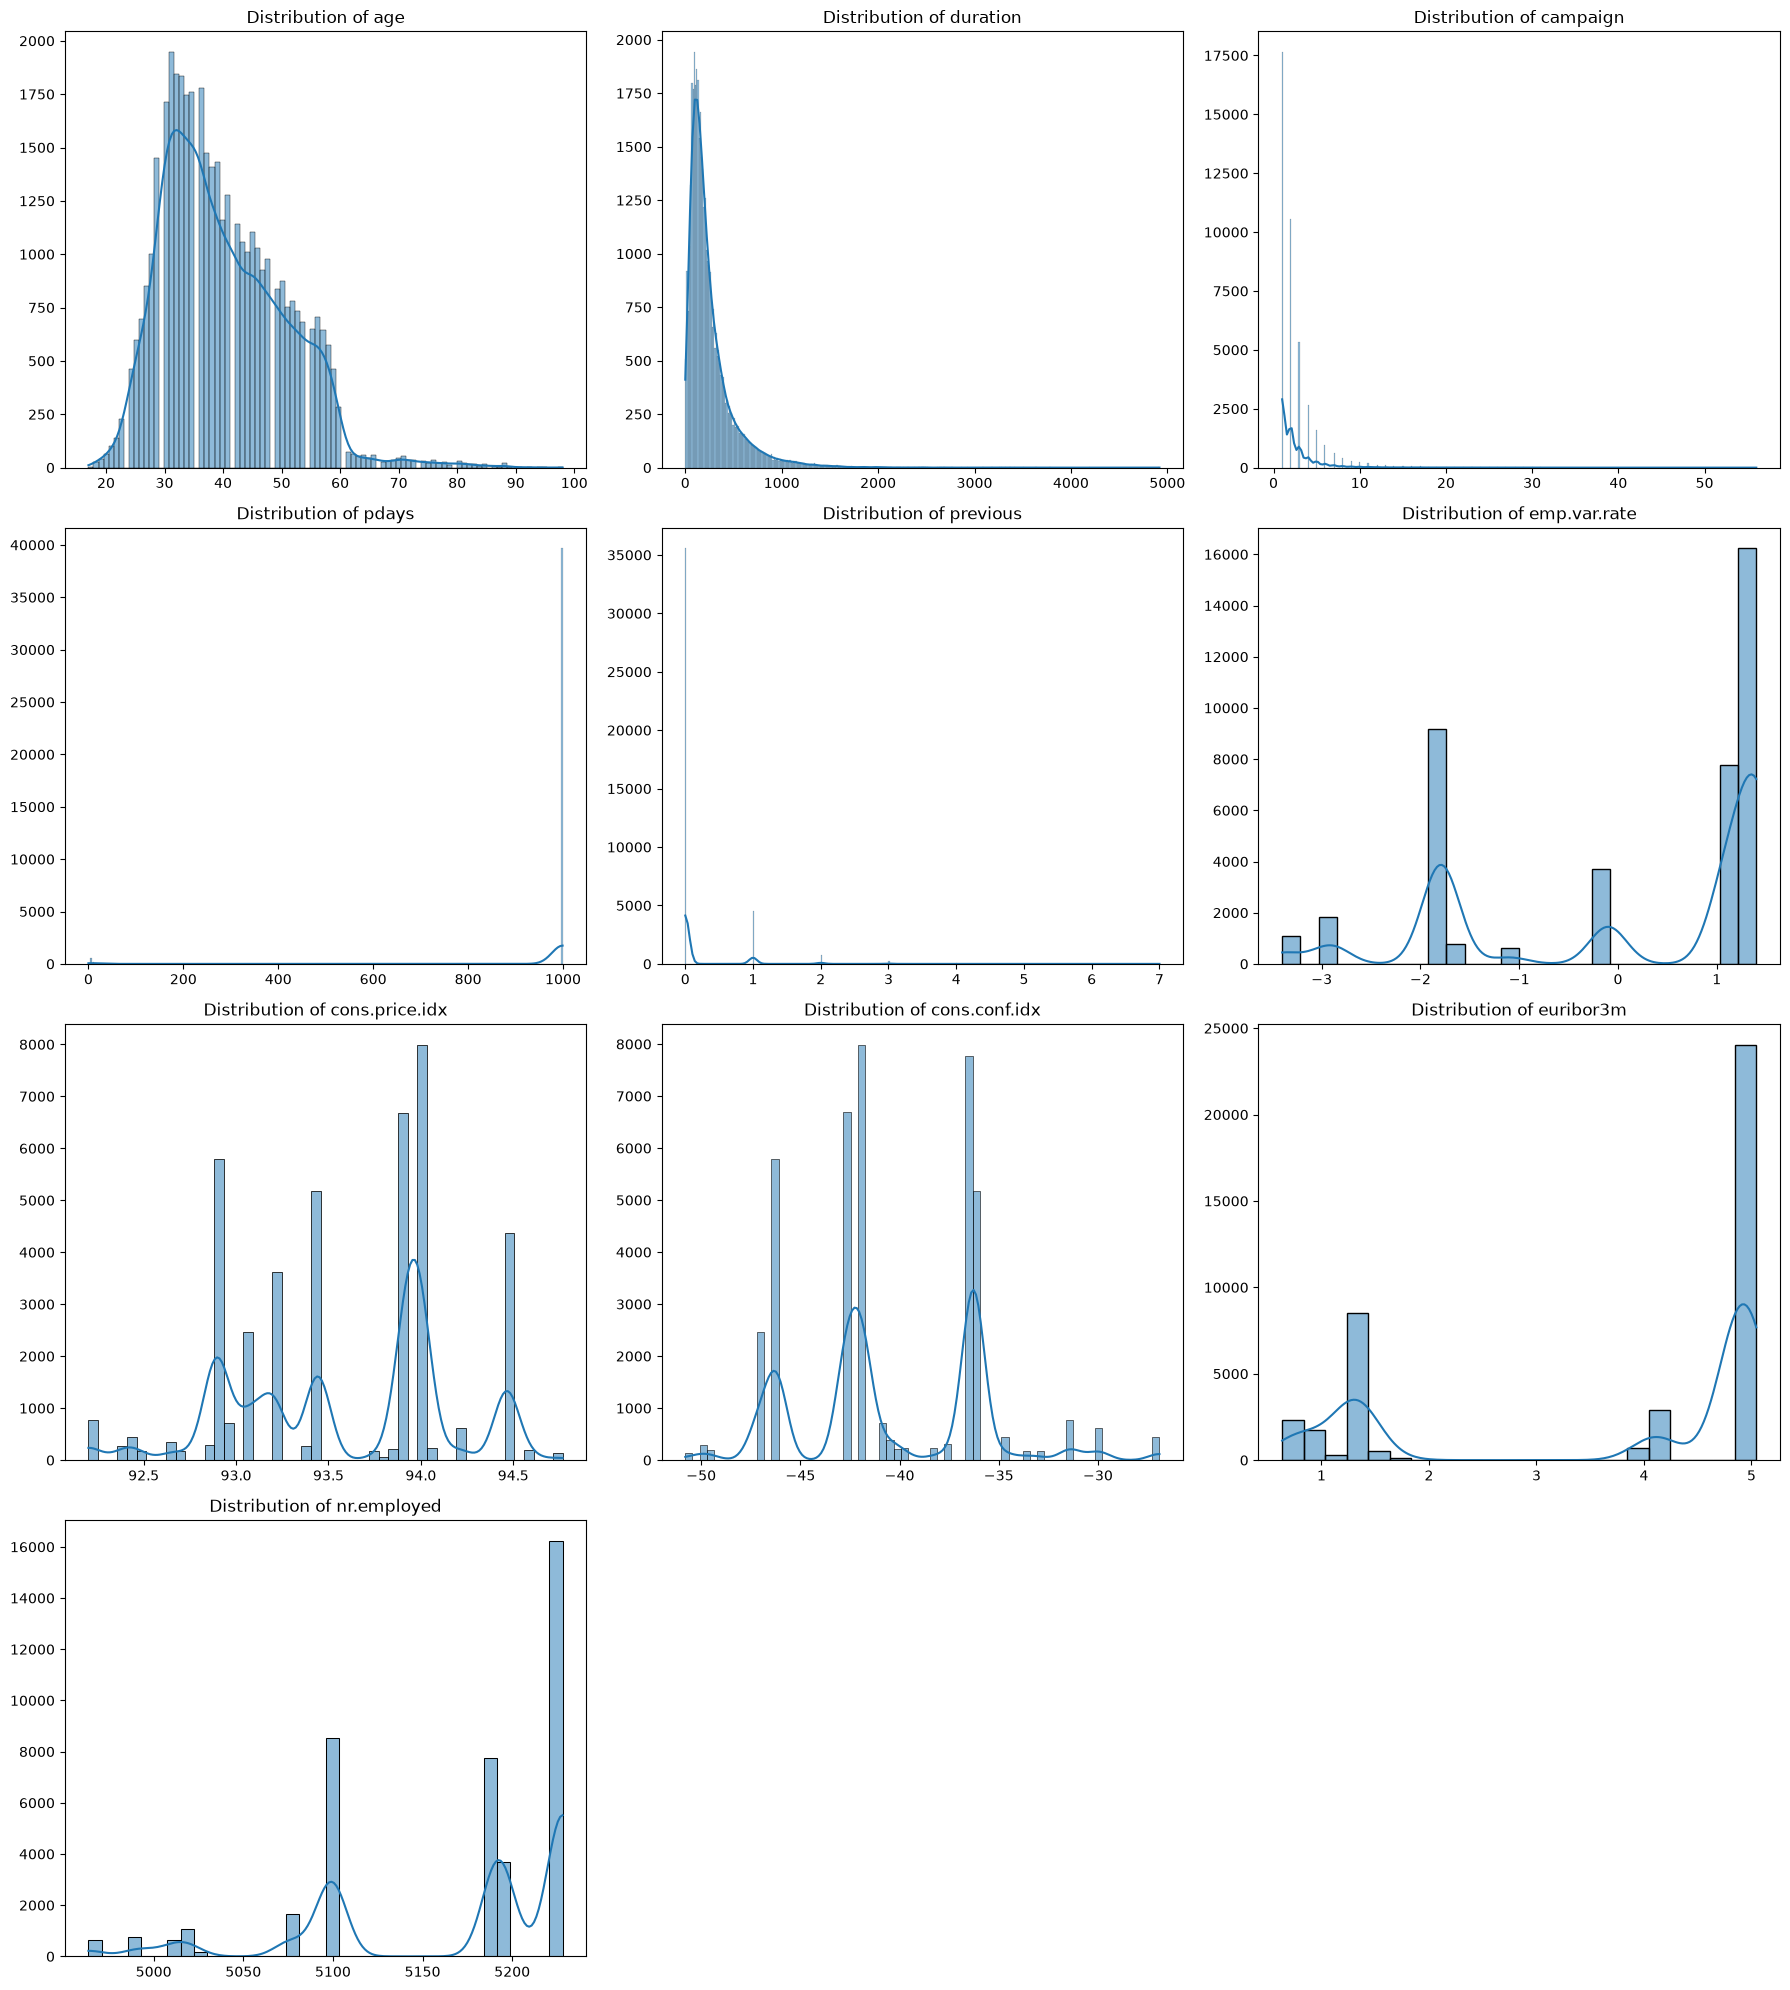

In [18]:
fig,axes=plt.subplots(nrows=4,ncols=3, figsize=(18,20))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    if i < len(axes):
        sns.histplot(df[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
    else:
        break
for j in range(i +1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show

Observation: it shows the distributions of subscriptions with different numerical features.

## Correlation HeatMAP

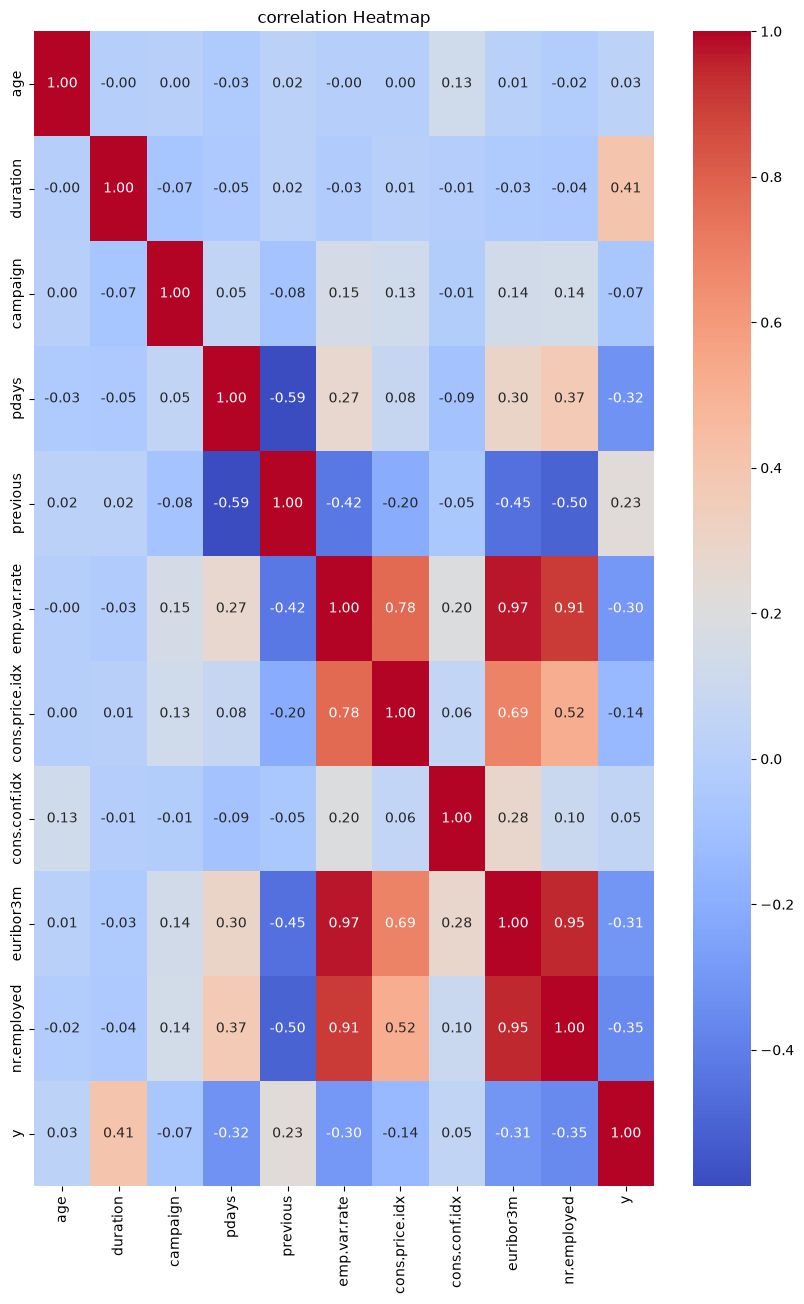

In [62]:
numeric_cols=df.select_dtypes(include=np.number)
plt.figure(figsize=(10,15))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("correlation Heatmap")
plt.show()

observation:The heatmap of correlations is used for the analysis between different numerical variables in the context of the dataset related to bank marketing. The variables emphasize a weak to moderate relationship, which allows the model to capture unique information.The heat map significantly helps in identifying the variables that are correlated with each other.

## Feature Engineering

In [20]:
df_cleaned= df.drop('duration', axis=1)


observation: droped the column duration from the dataset.

*Age group*

In [21]:
def age_group(age):
    if age < 25:
        return "Young"
    elif age < 35:
        return "Adult"
    elif age < 50:
        return "Middle_Age"
    elif age < 65:
        return "Senior"
    else:
        return "Elderly"
df_cleaned["age_group"]=df["age"].apply(age_group)
df_cleaned[["age","age_group"]].head()

,age,age_group
0,56,Senior
1,57,Senior
2,37,Middle_Age
3,40,Middle_Age
4,56,Senior


observation: The variable age has been categorized to allow for possible nonlinear relations with subscription behavior. There may be differences in customer behavior between youthful, middle-aged, and older customers, and grouping age into categories may help some models identify the pattern.

*Pdays column: replaced 999 with nan*

In [22]:
df_cleaned["pdays_clean"]=df_cleaned["pdays"].replace(
    999,
    np.nan
)
df_cleaned[["pdays","pdays_clean"]].head()

,pdays,pdays_clean
0,999,NaN
1,999,NaN
2,999,NaN
3,999,NaN
4,999,NaN



Observation:The pdays variable has -1 to show that the customer has not been contacted in any prior campaign. Instead of treating -1 as a standard number, a binary feature process has been adopted and changed to NaN.This process improves the clarity of the feature. 

*Total_contact_intensity*

In [23]:
df_cleaned["total_contact_Intensity"]=(
    df_cleaned["campaign"] + df["previous"]
)
df_cleaned.total_contact_Intensity

0        1
1        1
2        1
3        1
4        1
        ..
41183    1
41184    1
41185    2
41186    1
41187    4
Name: total_contact_Intensity, Length: 41188, dtype: int64

observation: A new characteristics representing total contact intensity was developed by combining the number of contacts made in the current campaign with the contacts made in the previous campaigns. 
This characteristics provides an overall representation of the frequency of customer contact with the bank. It may help assess whether customary marketing communication can influence the likelihood of subscription.

## Prepare And Splitting of Data 

In [24]:
df_cleaned.drop(columns="pdays")

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,age_group,pdays_clean,total_contact_Intensity
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,Senior,NaN,1
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,Senior,NaN,1
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,Middle_Age,NaN,1
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,Middle_Age,NaN,1
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,Senior,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1,Elderly,NaN,1
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0,Middle_Age,NaN,1
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0,Senior,NaN,2
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1,Middle_Age,NaN,1


In [25]:
x= df_cleaned.drop(columns=["y"])
y= df_cleaned["y"]


In [26]:
X_train,X_test,y_train,y_test =train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
print(X_train.shape)
print(X_test.shape)

(32950, 22)
(8238, 22)


observation: the data set was divided into test 20 percent and train 80 percent 

*Identify numerical and Categorical Features*

In [27]:
from sklearn.impute import SimpleImputer
numeric_cols= X_train.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object","str","category","bool"]).columns.tolist()

numerical_transformer =Pipeline([ 
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder",OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))])

preprocessor = ColumnTransformer([
        ('num', numerical_transformer,numeric_cols),
        ('cat', categorical_transformer,categorical_cols)
    ])


observation: In order to safeguard against data leakage, the preprocessing took place after dividing the dataset into the training and testing sets. The numerical missing values were filled in via median and then scaled while for categorical values most common value and OrdinalEncoder were employed in the filling process. ColumnTransformer was utilized to apply the data preprocessing which was compatible with the kind of feature in the course of model training.

## Model Training

*Logistic Regression*

In [28]:
logistic_model =Pipeline([
    ("preprocessor",preprocessor),
    ("classifier",LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        C=1,
        solver="liblinear",
        random_state=42
    ))
])
logistic_model.fit(X_train,y_train)
y_pred=logistic_model.predict(x)





In [29]:
print(classification_report(y,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.83      0.89     36548
           1       0.33      0.64      0.43      4640

    accuracy                           0.81     41188
   macro avg       0.64      0.74      0.66     41188
weighted avg       0.88      0.81      0.84     41188



observation: The Logistic Regression model had an accuracy score of around 81%, yet the F1-score was significantly lower. Thus, we can draw the conclusion that accuracy is not enough when assessing an imbalanced classification task.

## Decision Trees

In [30]:
decision_tree_model= Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",DecisionTreeClassifier(criterion="gini",max_depth=10,min_samples_leaf=10,min_samples_split=20,class_weight="balanced",random_state=42))
])
decision_tree_model.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['age','job','marital',...,'age_group','pdays_clean', 'total_contact_Intensity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passth

In [31]:
y_pred=decision_tree_model.predict(x)
print(classification_report(y,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.88      0.91     36548
           1       0.40      0.64      0.49      4640

    accuracy                           0.85     41188
   macro avg       0.67      0.76      0.70     41188
weighted avg       0.89      0.85      0.87     41188



observation:The increase of F1 score from around 0.43 to 0.49 means that the balance between the precision and recall was improved. Not only that, the model was capable of understanding the more complex relationships present in the data.



## Random Forest

In [32]:
random_forest_model= Pipeline([
    ("preprocessor",preprocessor),
    ("classifier",RandomForestClassifier(n_estimators=300,max_depth=15,min_samples_leaf=5,min_samples_split=10,class_weight="balanced",random_state=42,n_jobs=-1))
])
random_forest_model.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['age','job','marital',...,'age_group','pdays_clean', 'total_contact_Intensity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passth

In [33]:
y_pred=random_forest_model.predict(x)
print(classification_report(y,y_pred))


              precision    recall  f1-score   support

           0       0.96      0.89      0.92     36548
           1       0.45      0.71      0.55      4640

    accuracy                           0.87     41188
   macro avg       0.71      0.80      0.74     41188
weighted avg       0.90      0.87      0.88     41188



observation:The increase in F1-score shows that Random Forest has managed to create a good equilibrium between identifying potential subscribers and minimizing false positive predictions.The ensemble technique enabled the system to model complex relations, without the risk of overfitting that is characteristic of an individual Decision Tree.


## Gradient Boosting

In [34]:
gradient_boosting_model = Pipeline([
    ("preprocessor",preprocessor),
    ("classifier", GradientBoostingClassifier(n_estimators=200,
    learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=42
    ))
])
gradient_boosting_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['age','job','marital',...,'age_group','pdays_clean', 'total_contact_Intensity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passth

In [35]:
y_pred=gradient_boosting_model.predict(x)
print(classification_report(y,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95     36548
           1       0.72      0.26      0.39      4640

    accuracy                           0.91     41188
   macro avg       0.82      0.63      0.67     41188
weighted avg       0.89      0.91      0.89     41188



observation: Accuracy of 91%, Gradient Boosting obtained the best accuracy. Nonetheless, its recall was considerably less than that of the other models.The truth is that even with the maximum accuracy, the model detected only around 26% of true customers. Thus, it showed poor performance in finding the minority positive class.

### Models Evaluation

In [51]:
models = {
    "logistic regression":logistic_model,
    "Decision Tree":decision_tree_model,
    "Random Forest":random_forest_model,
    "Gradient Boosting":gradient_boosting_model
}
results =[]
for name, model in models.items():
    y_pred = model.predict(x)
    results.append({
        "Model":name,
        "Accuracy": accuracy_score(y,y_pred),
        "Precision": precision_score(y,y_pred,zero_division=0),
        "Recall": recall_score(y,y_pred,zero_division=0),
        "F1 score": f1_score(y,y_pred,zero_division=0),
        "ROC": roc_auc_score(y,y_pred)
    })
comparison=pd.DataFrame(results)
print(comparison)

                 Model  Accuracy  Precision    Recall  F1 score       ROC
0  logistic regression  0.811911   0.327905  0.637931  0.433160  0.735965
1        Decision Tree  0.850660   0.399038  0.643534  0.492617  0.760245
2        Random Forest  0.870909   0.453201  0.706466  0.552177  0.799126
3    Gradient Boosting  0.905506   0.719484  0.264224  0.386507  0.625573


*Oberservartion:* The analysis shows that none of the models are better than others in every aspect. Gradient Boosting has the maximum accuracy and precision but low recall. This indicates that even though its positive predictions were quite accurate, it missed many real subscribers. Random Forest has the highest F1 score and impressively high recall. Given that the dataset is skewed and the main goal of the business is to identify subscribers, Random Forest achieves a good compromise between recall and precision.Thus, choosing a model should be based on business goals, not just on accuracy.

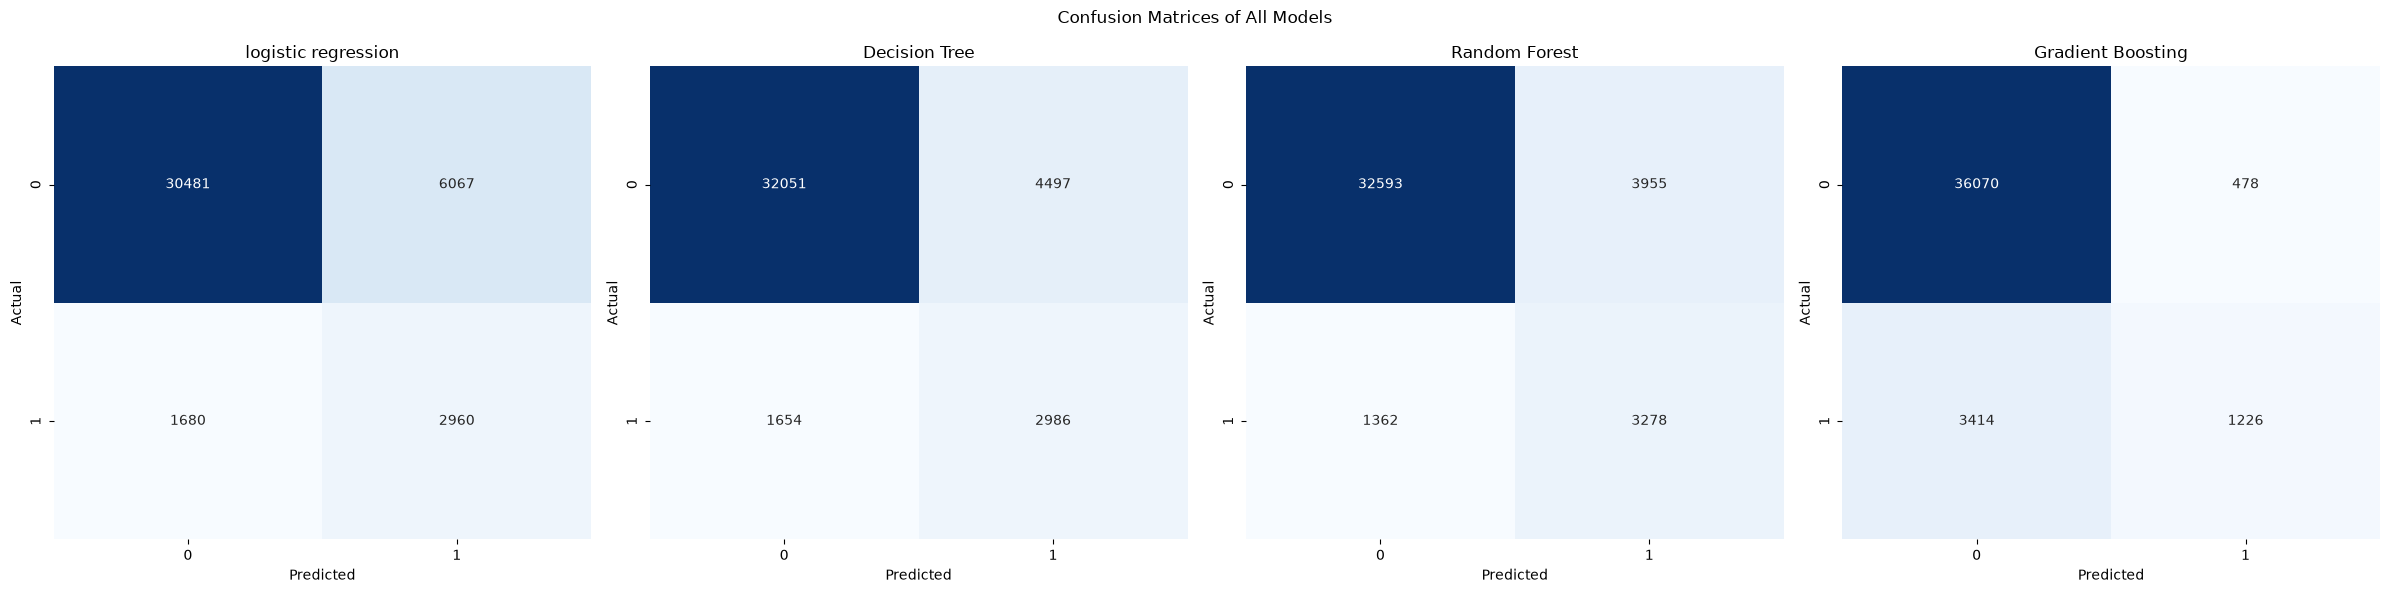

In [52]:
fig,axes=plt.subplots(1,len(models),figsize=(6*len(models),6))
for ax,(name,model) in zip(axes,models.items()):
    y_pred=model.predict(x)
    cm=confusion_matrix(y,y_pred)
    sns.heatmap(cm,annot=True,fmt='d',cmap="Blues",ax=ax,cbar=False)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices of All Models")
plt.tight_layout()
plt.show()

Observation: Random Forest tends to exhibit a higher number of false negatives which suggests their default setting is to underestimate the minority class value. In contrast, Gradient Boosting expereinece more false positives than expected. Such errors help prioritize hyperparameter tuning tasks ahead.

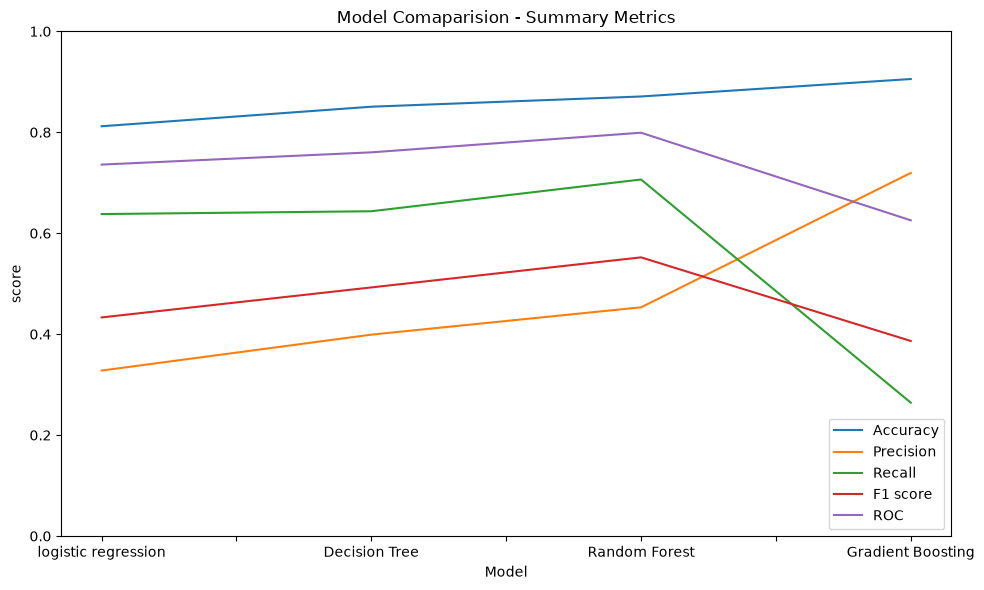

In [56]:
comparison.set_index("Model")[["Accuracy","Precision","Recall","F1 score","ROC"]].plot(
    kind="line",figsize=((10,6))
)
plt.title("Model Comaparision - Summary Metrics")
plt.ylabel("score")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Observation: this line chart visualizes that Random Forest is the best model to use as it has high Accuracy,Recall and f1score along with low precison compared to other models.

## Hyperparameters Tuning

In [41]:
param_grid_logistic = {
    "classifier__C":[0.01,0.1,1,10],
    "classifier__class_weight":[None]
}
grid_logistic = GridSearchCV(
    estimator=logistic_model,
    param_grid=param_grid_logistic,
    cv=5,
    scoring="accuracy",
    n_jobs=1,
    error_score="raise"
)
grid_logistic.fit(X_train,y_train)
best_logistic_model = grid_logistic.best_estimator_
print(grid_logistic.best_params_)
print(grid_logistic.best_score_)


{'classifier__C': 1, 'classifier__class_weight': None}
0.9003034901365705


observation: LogisticRegression shows that to get better prediction we should use these parameters{'classifier__C': 1, 'classifier__class_weight': None} 

In [42]:
dt_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("classifier",DecisionTreeClassifier(random_state=42))
])
param_grid_dt={
    "classifier__criterion":["entropy"],
    "classifier__max_depth":[5,10,None],
    "classifier__min_samples_split":[2,5,10],
    "classifier__min_samples_leaf":[1,2,5],
    "classifier__class_weight":[None]
}
grid_dt=GridSearchCV(
    dt_pipeline,param_grid_dt,cv=5,scoring="accuracy", n_jobs=-1
)
grid_dt.fit(X_train,y_train)
best_decision_tree=grid_dt.best_estimator_
print(grid_dt.best_params_)
print(grid_dt.best_score_)
print(best_decision_tree.score(x,y))

{'classifier__class_weight': None, 'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
0.9000910470409712
0.9025444304166262


Observation: Decision Tree shows that these parameters classifier__class_weight': None, 'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2 would give a better predictions.

In [43]:
rf_pipeline = Pipeline([
    ("preprocessor",preprocessor),
    ("classifier",RandomForestClassifier(random_state=42,n_jobs=1))
])
param_grid_rf={
    "classifier__n_estimators":[200],
    "classifier__max_depth":[10,20,None],
    "classifier__min_samples_split":[2,5,10],
    "classifier__min_samples_leaf":[1,2,5],
    "classifier__max_features":["sqrt","log2"],
    "classifier__class_weight":[None]
}
grid_rf = GridSearchCV(estimator=rf_pipeline,param_grid=param_grid_rf,cv=5,)
grid_rf.fit(X_train,y_train)
best_random_forest=grid_rf.best_estimator_
print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'classifier__class_weight': None, 'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
0.899969650986343


Observation: RandomForest shows us that using these parameters {'classifier__class_weight': None, 'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200} would give a better predictions.

In [45]:
gb_pipeline =Pipeline([
    ("preprocessor",preprocessor),
    ("classifier",GradientBoostingClassifier(random_state=42))
])
param_grid_gb ={
    "classifier__n_estimators":[100,200],
    "classifier__learning_rate":[0.01,0.05,0.1],
    "classifier__max_depth":[2,3,5],
    "classifier__min_samples_split":[2,6,11],
    "classifier__min_samples_leaf":[1,2,5]
}
grid_gb = GridSearchCV(gb_pipeline,param_grid_gb,cv=5,scoring="accuracy",n_jobs=-1)
grid_gb.fit(X_train,y_train)
best_gradient_boosting= grid_gb.best_estimator_
print(grid_gb.best_params_)
print(grid_gb.best_score_)


{'classifier__learning_rate': 0.1, 'classifier__max_depth': 2, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
0.9007587253414264


Observations GradeintBoosting should use parameters shown after testing all the cobinations for getting a better predictions 

In [46]:
tuned_models ={
    "logistic Regreesion HP":best_logistic_model,
    "Decision Tree HP":best_decision_tree,
    "Random Forest HP":best_random_forest,
    "Gradient Boosting HP":best_gradient_boosting
}
results = []
for name, model in tuned_models.items():
    y_pred=model.predict(x)
    y_prob =model.predict_proba(x)[:,1]
    results.append({
        "Model":name,
        "Accuracy":accuracy_score(y,y_pred),
        "Precision":precision_score(y,y_pred,zero_division=0),
        "Recall":recall_score(y,y_pred,zero_division=0),
        "F1 Score":f1_score(y,y_pred,zero_division=0),
        "ROC-AUC":roc_auc_score(y,y_prob)
    })
tuned_comparision=pd.DataFrame(results)
print(tuned_comparision)

                    Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  logistic Regreesion HP  0.900408   0.680054  0.218966  0.331268  0.786714
1        Decision Tree HP  0.902544   0.652089  0.289224  0.400717  0.785198
2        Random Forest HP  0.910047   0.782477  0.279095  0.411438  0.839140
3    Gradient Boosting HP  0.902933   0.706830  0.236422  0.354328  0.804569


Observation: After hyperparameter tuning randomForest has still being the best model to choose as its accuracy,Precision,f1score are higher than other models.

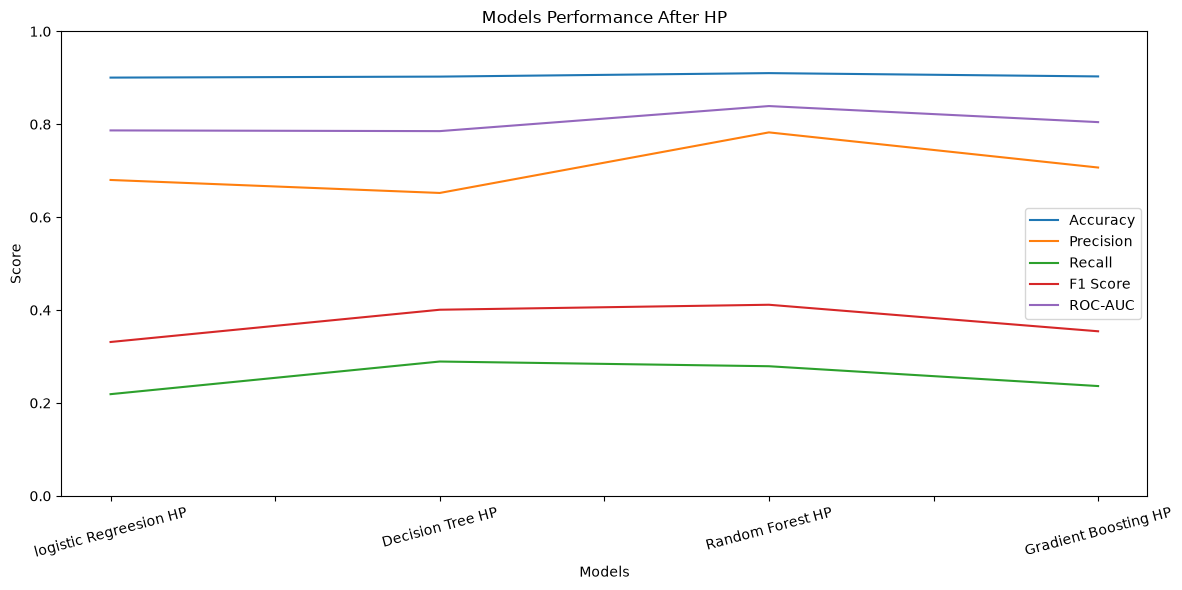

In [57]:
tuned_comparision.plot(
    x="Model",
    y=["Accuracy","Precision","Recall","F1 Score","ROC-AUC"],
    kind="line",
    figsize=(12,6) 
)
plt.title("Models Performance After HP")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()


Observation: After appling hyperparmeters random Forest has still the highest evaluation metrics like accuracy,precision,Recall than other models

## Final Model 

In [58]:
y_test_pred = best_random_forest.predict(X_test)
print(classification_report(y_test,y_test_pred))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.69      0.24      0.35       928

    accuracy                           0.90      8238
   macro avg       0.80      0.61      0.65      8238
weighted avg       0.89      0.90      0.88      8238



Observation: ran the randomforest model on unseen data 

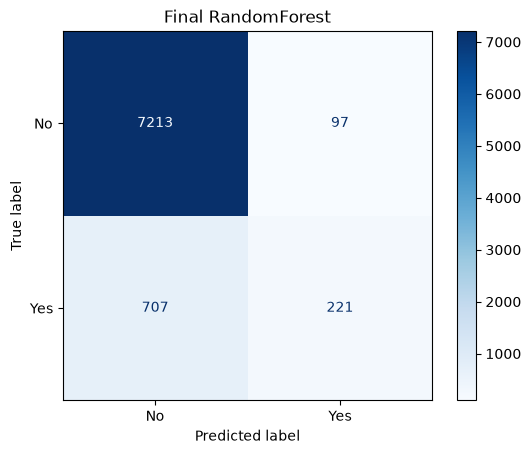

In [60]:
cm= confusion_matrix(y_test,y_test_pred)
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No","Yes"]
)
display.plot(cmap="Blues")
plt.title("Final RandomForest")
plt.show()

Observation:  it has predict ture positives better than before.

## Feature Importance

In [ ]:
importance = best_random_forest.named_steps["classifier"].feature_importances_
feature_names = numeric_cols + categorical_cols 
feature_importance = pd.DataFrame({
    "Feature":feature_names,
    "Importance":importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False

)
print(feature_importance.head(10))

           Feature  Importance
7        euribor3m    0.189253
8      nr.employed    0.176732
2            pdays    0.100588
20        poutcome    0.082238
6    cons.conf.idx    0.062117
4     emp.var.rate    0.058724
5   cons.price.idx    0.052275
0              age    0.047808
18           month    0.039894
9      pdays_clean    0.022480


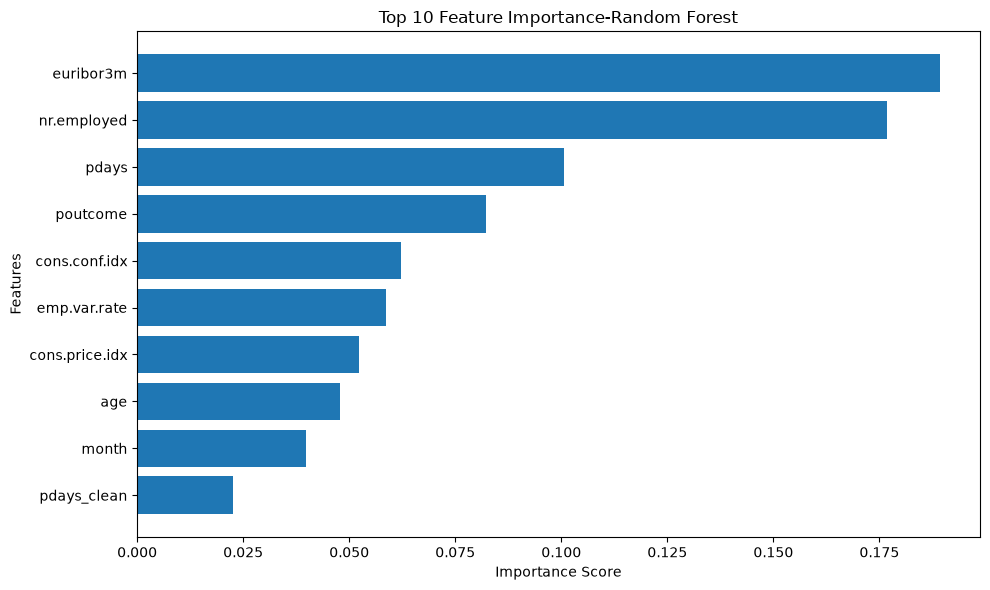

In [ ]:
top_features = feature_importance.head(10)
plt.figure(figsize=(10,6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Feature Importance-Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Observation The analysis of feature importance indicates which factors were the most impactful in reaching the conclusions of the final model. Features that received higher importance scores are the ones that have contributed positively towards predicting whether the customer will sign up for a term deposit or not. In this way, it helps identify the most relevant characteristics of a customer or a campaign in terms of marketing decisions.

## Strengths:
- The Random Forest model achived outstanding results in terms of overall performance
- A number of machine learning algorthms were investigated to discover the most efficacious 
- Data preprocessing was able to deal with missing data, normalization, and categorical encoding efficient.
- The optimization of hyperparameters allowed for better results for models that had been selected.
- importance analysis of variables made it possible to identify the factors that determine customer subscriptions sucessfully

## Limitations:
- The dataset has an imbalance with regard to customers subscribers who might be limited.
- The accuracy metric alone can be misguiding hence it is necessary to use precision,recall and F1 score.
- Some of the features are probable to be not distinguished in real life before contacting the customers


## Business Recommandation:
- The model assist the banks in determing the customers that have a stronger possibilty of subscribing.
- Targeted marketing minimizes excessive calls and operational costs.
- Bank employees can allot their efforts towards the valuable customers.
- Better targeting mean that the efficitiveness of the campigns and conversions improves.
- the model will ficilitate the data based decision making process in the next marketing programs.

## Conclusion:
The project was able to create machine learning techniques to foresee customers who are likely to subscribe to term deposits. 
The Random Forest model did better overall than the other models tested. 
The use of different metrics provided more insight into the model performance on the unbalanced dataset.
The model will aid in better targeting of the customer and the reduction of marketing costs.
The project will need to address the data imbalance and remove some leakage features like duration in the future.

By WALEED ABUL KHAIR 
GH1060565
